## Step 1: Import the required modules and define plotting preferences

### Download and install important modules

In [6]:
!pip install impedance
import importlib
import Manuel_echem_function
importlib.reload(Manuel_echem_function)
from Manuel_echem_function import *
import pandas as pd
import os, io
import requests
import numpy as np
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize
import sys
from nomad_api_calls import *

%matplotlib widget

import warnings
warnings.filterwarnings("ignore")



### Define plotting preferences 

In [2]:

## Plotting preferences 

color_cm = ["#004f84ff", "#6cabe9ff", "#d15e57ff", "#ff7f2aff","#808080ff","#8787deff"]
# Expanded with 5 additional colors that harmonize with the original palette
color_cm = color_cm + ["#00a591ff", "#b2df8aff", "#f9c74fff", "#178eaeff", "#a70d88ff", "#373438ff",]

matplotlib.rc('font', size= 14) # controls default text sizes
matplotlib.rc('axes', titlesize=14) # fontsize of the axes title
matplotlib.rc('axes', labelsize=14) # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=14) # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=14) # fontsize of the tick labels
matplotlib.rc('legend', fontsize= 10) # legend fontsize
matplotlib.rc('figure', titlesize=14) # fontsize of the figure title


## Step 2: Authenticate to NOMAD to retrive data

In [3]:
url = "https://nomad-hzb-se.de/nomad-oasis/api/v1"
token = os.environ['NOMAD_CLIENT_ACCESS_TOKEN'] 
if len(token) > 10:
    print("Token Recieved")

Token Recieved


## Step 3: Download electrochemical data

In [11]:
# Format batch ID per subbatch 
file_id=[["HZB_Echem_162_5_C-35","HZB_Echem_162_5_C-34"], #2
         ["HZB_Echem_162_4_C-27","HZB_Echem_162_4_C-28"], #1 
         ["HZB_Echem_162_3_C-21","HZB_Echem_162_3_C-20"], #0.5
         ["HZB_Echem_162_2_C-14","HZB_Echem_162_2_C-13"], #0.25
         ["HZB_Echem_162_1_C-6","HZB_Echem_162_1_C-7"],   #0.125
         ["HZB_Echem_161_9_C-21",  "HZB_Echem_161_9_C-23"]] #0

file_id.reverse()

# This concentration is manual for now, there are some corrections needed in the metadata (I am working on it) 
concentration = np.array([
    2.0,         # HZB_Echem_162_5
    1.0,         # HZB_Echem_162_4
    0.5,         # HZB_Echem_162_3
    0.25,        # HZB_Echem_162_2
    0.125,       # HZB_Echem_162_1
    0.0          # HZB_Echem_161_9 + 162_6
])
concentration = concentration[::-1]

#### Download data from NOMAD

flat_file_id = [item for sublist in file_id for item in sublist]

dataEIS=get_specific_data_of_samples_all(url, token, flat_file_id, "HySprint_ElectrochemicalImpedanceSpectroscopy")   # This function use the sample IDs to search for the NOMAD for impedance data
dataDPV=get_specific_data_of_samples_all(url, token, flat_file_id, "HySprint_DifferentialPulseVoltammetry")           # This function use the sample IDs to search for the NOMAD for DPV data
dataCV=get_specific_data_of_samples_all(url, token, flat_file_id, "HySprint_CyclicVoltammetry")                       # This function use the sample IDs to search for the NOMAD for Cyclic voltammetry


## Step 4: Plot the data

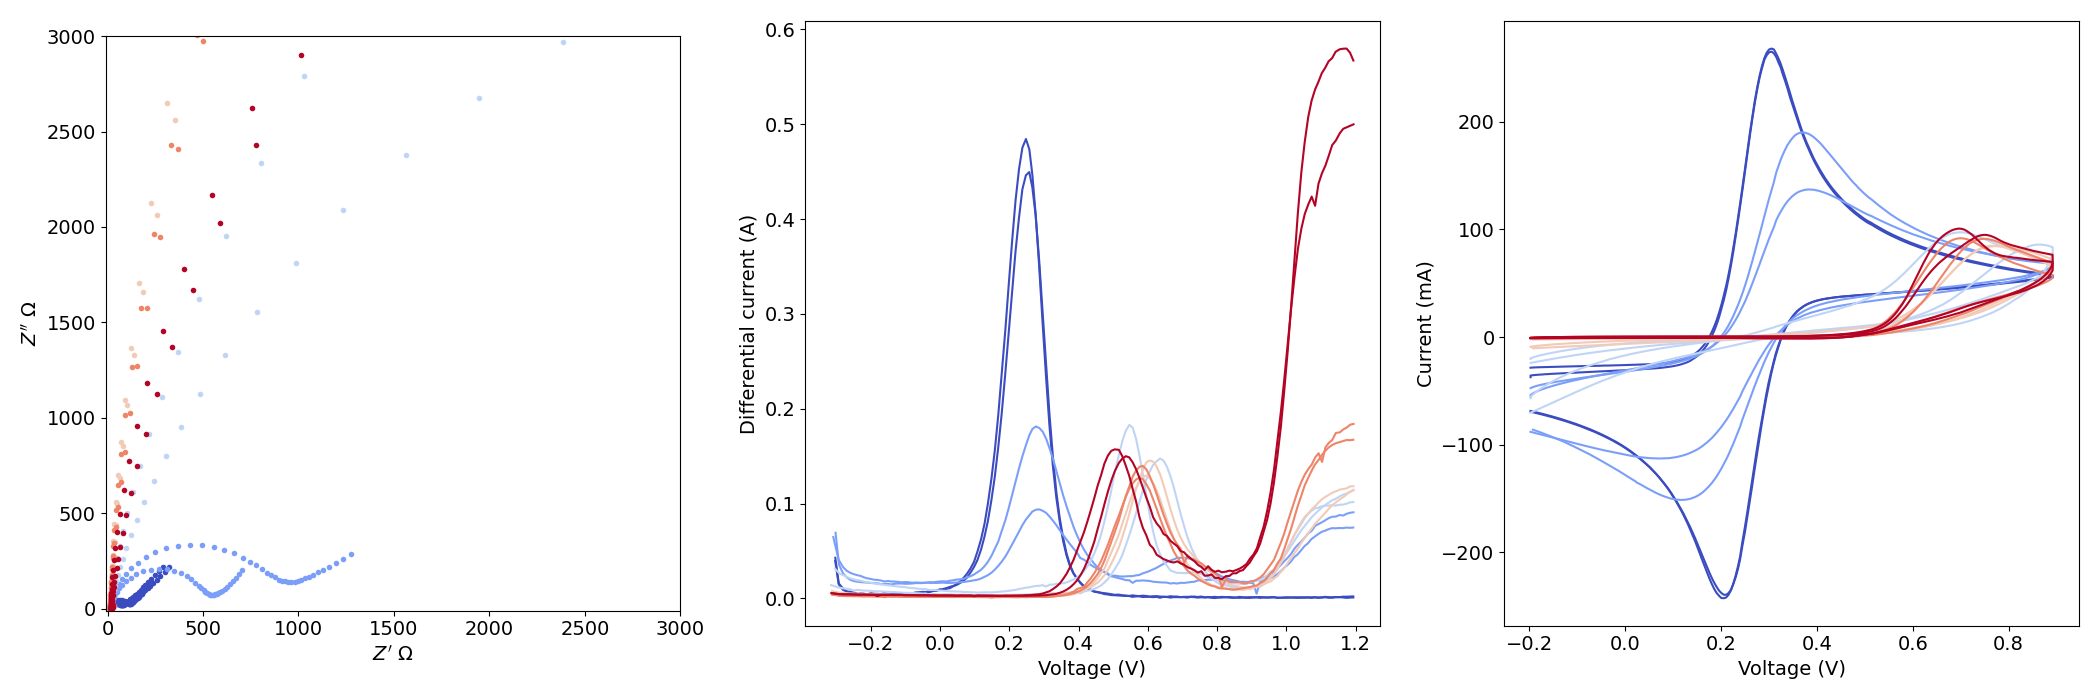

In [27]:
plt.close("all")

# Get the cividis colormap
cmap = plt.get_cmap("coolwarm")
# Create an array of 10 colors
colors = cmap(np.linspace(0, 1, len(concentration)))


fig,axis=plt.subplots(1,3,figsize=(7*3, 7) )

## This is important for the cylic voltammetry analysis 
reference_values=[0.05,0.1,0.2,0.3,0.5]  # Set of scan speed
threshold=0.02                           # Threshold for the detection of jumps. Used in CV_analysis_NOMAD 
scan_speed=0.05                          # Set the scan speed 
cycle_number=1                           # Number of cycle to plot 

label_experiment=[]
for jj,subbatch in enumerate(file_id):
    
    color=colors[jj]
    for ii,file in enumerate(subbatch):
         
        if ii==0:            
            #Get Concentration and SAM information from NOMAD
            A=get_sample_description(url, token, [file])
            label=f"{concentration[jj]:.2f} mg/mL"
            label_experiment.append(f"{concentration[jj]:.2f} mg/mL")
        else: 
            label=None

        
        ## EIS plot
        axs=axis[0]
        for idx, entry in enumerate(dataEIS):
            if file == entry["samples"][0]["lab_id"]:
                # Download data from dataEIS[idx]
                axs.plot(entry["z_real"],entry["z_imaginary"],"o",color=color,
                         label=label,alpha=1,markersize=4, markeredgecolor='none')
        
                axs.set_aspect('equal')
                axs.set_xlabel(r"$Z'$ $\Omega$")
                axs.set_ylabel(r"$Z''$ $\Omega$")
                axs.set_xlim([-10,3000])
                axs.set_ylim([-10,3000])   
                #axs.legend()
                break
                
        ## DPV plot
        axs=axis[1]
        for idx, entry in enumerate(dataDPV):
            if file == entry["samples"][0]["lab_id"]:
                # Download data from dataEIS[idx]
                axs.plot(entry["voltage"],entry["current"],color=color,label=label,alpha=1)   # From NOMAD current is equal to the differential current
                axs.set_xlabel(r"Voltage (V)")
                axs.set_ylabel(r"Differential current (A)")  
                #axs.legend()        
                break
                
        ## CV plot
        axs=axis[2]
        for idx, entry in enumerate(dataCV):
            if file == entry["samples"][0]["lab_id"]:
                # Download data from dataEIS[idx]
                CV_df=CV_analysis_NOMAD(entry["cycles"][0]["time"],entry["cycles"][0]["voltage"],entry["cycles"][0]["current"],reference_values,threshold,plot_SS=False) #Function to assign scan speed
                
                df1 = CV_df[CV_df['Speed_bin'] == "0.05"]          #Filter by scan speed
                df1=assign_cycles_NOMAD(df1)                       #Separate the cycle number  
                df_cycle2 = df1[df1["Cycle"] == cycle_number]      #Filter data by cycle number
                
                axs.plot(df_cycle2["voltage"], df_cycle2["current"]*1e3,color=color, label=label,alpha=1)  # Plot
                axs.set_xlabel(r"Voltage (V)")
                axs.set_ylabel(r"Current (mA)")  
                #axs.legend()      
                break

# #plt.savefig("Overall_plot_Echem.png",dpi=500)
plt.tight_layout()
plt.savefig("Overall_plot_Echem.svg")

plt.show()


## Further analysis - Electrochemical impedance spectroscopy

0
[8.66077207e+01 1.72656962e+02 9.82947870e-06 9.96883788e-01]
[6.73819138e+01 1.70702487e+02 9.75048636e-06 1.00000000e+00]
[6.73819138e+01 1.70702487e+02 9.75048636e-06 1.00000000e+00]
[5.63271542e+01 1.76354284e+02 1.95479801e-05 8.88718463e-01]
[6.59520713e+01 1.74779689e+02 2.39335813e-05 8.64289401e-01]
[1.00482384e+02 1.68002260e+02 1.24042210e-05 9.60787400e-01]
[1.00482384e+02 1.68002260e+02 1.24042210e-05 9.60787400e-01]
1
[9.03968396e+02 2.55482196e+02 9.96668220e-06 8.08274243e-01]
[4.98548427e+02 1.58537445e+02 1.02059237e-05 8.79287350e-01]
2
[9.65001397e+03 8.14139534e+02 1.06238578e-05 8.17736400e-01]
[2.89281117e+04 5.92054500e-06 8.35669891e-01 5.72918108e+06]
3
[5.64205198e+04 2.00408028e-06 9.47527165e-01 1.14840986e+06]
[2.19605141e+04 3.78081952e-06 8.71904094e-01 4.47427629e+06]
[5.52316990e+04 2.41503679e-06 9.20145546e-01 1.96165839e+07]
4
[6.20083869e+04 2.72986022e-06 9.08215128e-01 3.37159006e+06]
[6.76830024e+04 2.79317115e-06 9.04652553e-01 1.91330617e+07

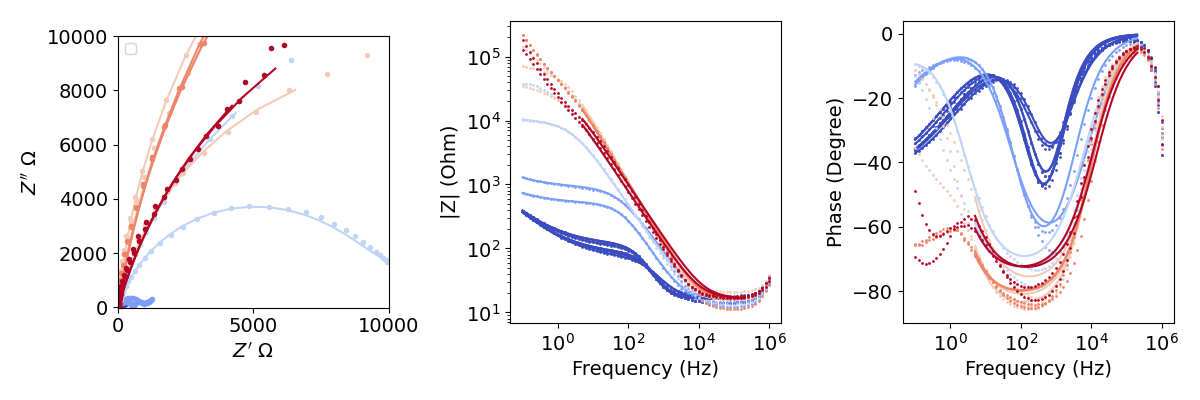

In [16]:
plt.close("all")

fig,axis=plt.subplots(1,3,figsize=(4*3, 4) )


Rct_experiment=[]
label_experiment=[]
for jj,subbatch in enumerate(file_id):
    
    color=colors[jj]
    print(jj)
    Rct=[]
    for ii,file in enumerate(subbatch):

        for idx, entry in enumerate(dataEIS):
            if file == entry["samples"][0]["lab_id"]:
                # Download data from dataEIS[idx]

                # Convert everything to NumPy arrays
                freq = np.array(entry["frequency"], dtype=float)
                Zr   = np.array(entry["z_real"], dtype=float)
                Zi   = -np.array(entry["z_imaginary"], dtype=float)
                Z = Zr + 1j * Zi

                # EIS fit
                    
                if np.max(Zr)<10000:

                    # Create mask for frequencies lower than 10^5 Hz
                    mask = (freq < 2e5) & (freq > 1e-2)   # or: mask = freq < 10**5
                    frequencies, Z = preprocessing.ignoreBelowX(freq[mask],Z[mask])
                
                    circuitA = 'R0-p(R2-W1,CPE1)'

                    initial_guess = [None, 86, 2e2, 9e-6,0.99]                #<-----------------------------------   Initial parameters for the impedance
                    constants={"R0":16.5}
                    Z_fit,circuit=impedance_fit2(frequencies,Z,circuitA,initial_guess,constants)
                    Rct.append(circuit.parameters_[1])
                    print(circuit.parameters_)
                    
                else:
                    
                    # Create mask for frequencies lower than 10^5 Hz
                    mask = (freq < 2e5) & (freq > 0.5e1)   # or: mask = freq < 10**5
                    frequencies, Z = preprocessing.ignoreBelowX(freq[mask],Z[mask])
                    
                    circuitA = 'p(R1,CPE1,R3)-R4'
                    initial_guess = [5e4, 3e-06, 0.9,1e7,None]                 #<-----------------------------------   Initial parameters for the impedance
                    
                    constants={"R4":16.2}
                    Z_fit,circuit=impedance_fit2(frequencies,Z,circuitA,initial_guess,constants)
                    Rct.append(circuit.parameters_[0])
                    print(circuit.parameters_)
            #else:
            #     circuitA='R0-p(R1,CPE1)-p(R2,CPE2)-p(R2,CPE2)'
            #     initial_guess=[None, 1e4, 1e-6,0.9,1e7,1e-6,0.9,1e8,1e-6,0.9]  # R0, R1, C1
            #     constants={"R0":16.5}
            #     Z_fit,circuit=impedance_fit2(frequencies,Z,circuitA,initial_guess,constants)

                
                ## EIS plot---------------------
                
                axs=axis[0]
                axs.plot(entry["z_real"],entry["z_imaginary"],"o",color=color,label=label,alpha=1,
                         markersize=4, markeredgecolor='none')

                axs.plot(np.real(Z_fit),-np.imag(Z_fit), "-",color=color,alpha=1)

                
                axs.set_aspect('equal')
                axs.set_xlabel(r"$Z'$ $\Omega$")
                axs.set_ylabel(r"$Z''$ $\Omega$")
                axs.set_xlim([-10,10000])
                axs.set_ylim([-10,10000])   
                axs.legend()
                
                axs=axis[1]
                axs.loglog(entry["frequency"],entry["z_modulus"],".",color=color,label=label,alpha=1, markersize=4, markeredgecolor='none')
                axs.loglog(frequencies,np.abs(Z_fit),"-",color=color,alpha=1)

                axs.set_ylabel("|Z| (Ohm)")
                axs.set_xlabel(r"Frequency (Hz)")

                axs=axis[2]
                axs.semilogx(entry["frequency"],entry['z_angle'], ".", color=color,alpha=1, markersize=4, markeredgecolor='none')
                axs.semilogx(frequencies,np.angle(Z_fit, deg=True), "-", color=color,alpha=1)

                axs.set_ylabel(r"Phase (Degree)")
                axs.set_xlabel(r"Frequency (Hz)")

    Rct_experiment.append(Rct)
plt.tight_layout()
plt.savefig("EIS_analysis.png",dpi=500)
